In [1]:
# importing the required libraries for our house price prediction project
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# data loading 
df = pd.read_csv("train.csv")
df.head()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# data exploring #EDA 
df.shape      # number of rows & columns. rows shows houses and coulmns shows features 1461houses and 81 features
df.info()     # data types & null values
df.describe() # summary statistics
# count telling us that how many non null values are there in a coulmn eg. id has no missing value that is all values
#are non null while poolqc has 7 non null values that is 1453 are null or missing values in this column .
#(total values or entries are 1460)
#info(): shows columns, data types, and missing values → tells you which are numeric and which are categorical.
#describe(): gives statistics (mean, min, max, etc.) → good for understanding numeric columns.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


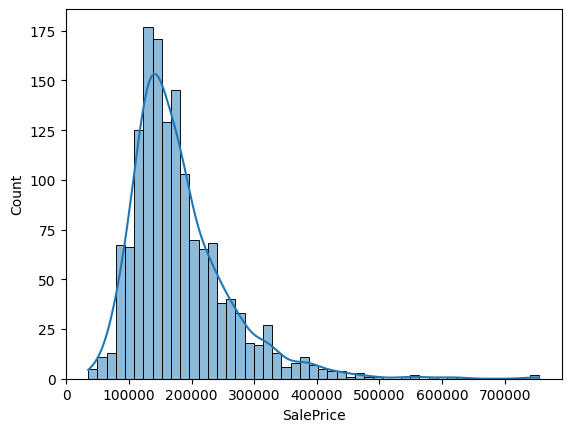

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"], kde=True)
plt.show()
#Histogram of target (SalePrice) → shows how house prices are spread.
#KDE (curve) = smooth line showing distribution.
#Often SalePrice is right-skewed (more low/medium-priced houses, few very expensive ones).
#If skewed, you may apply log(SalePrice) later → models work better with balanced distributions.


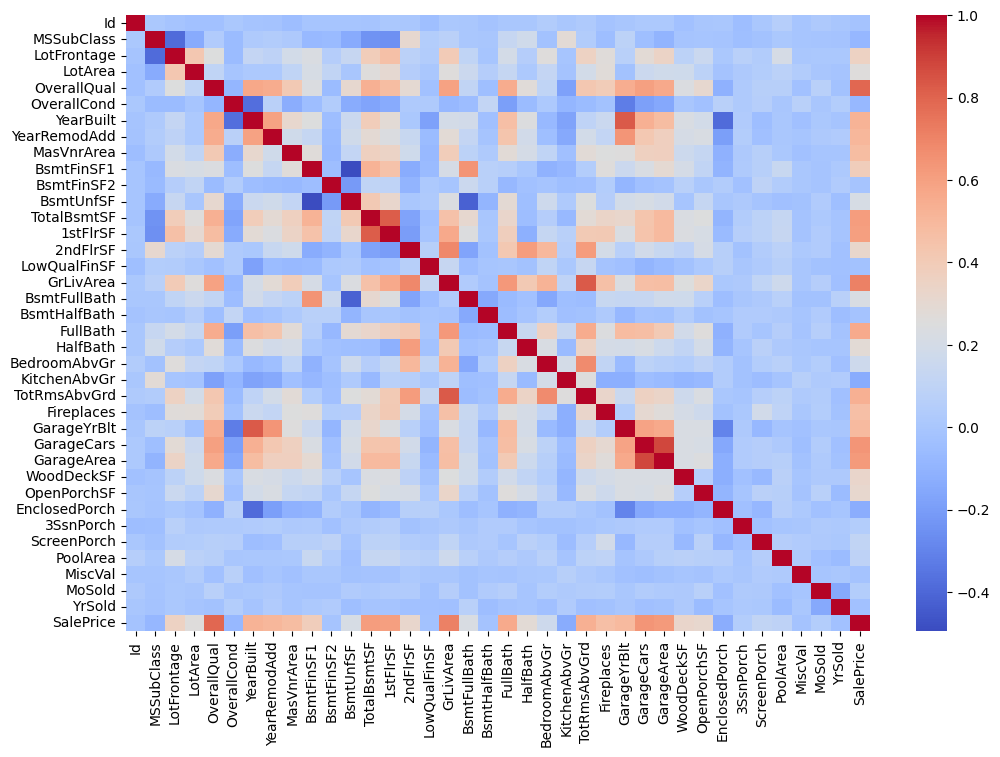

In [5]:
corr = df.select_dtypes(include=["number"]).corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.show()



In [6]:
corr["SalePrice"].sort_values(ascending=False).head(10)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

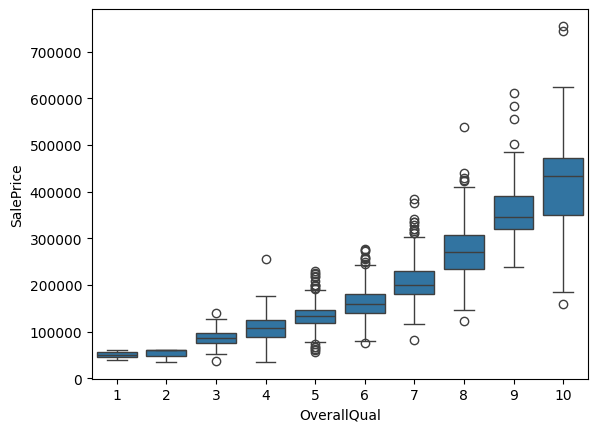

In [7]:
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.show()


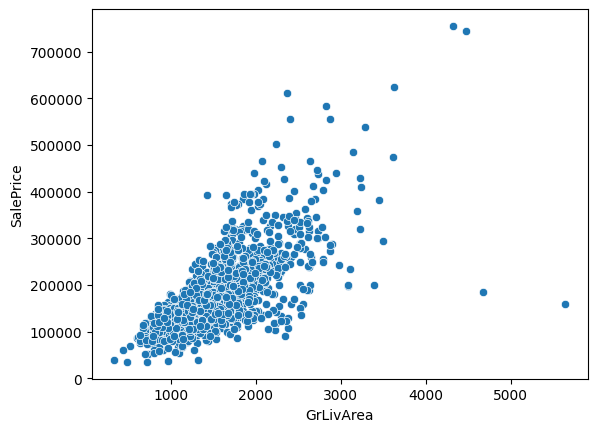

In [8]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.show()


<Axes: >

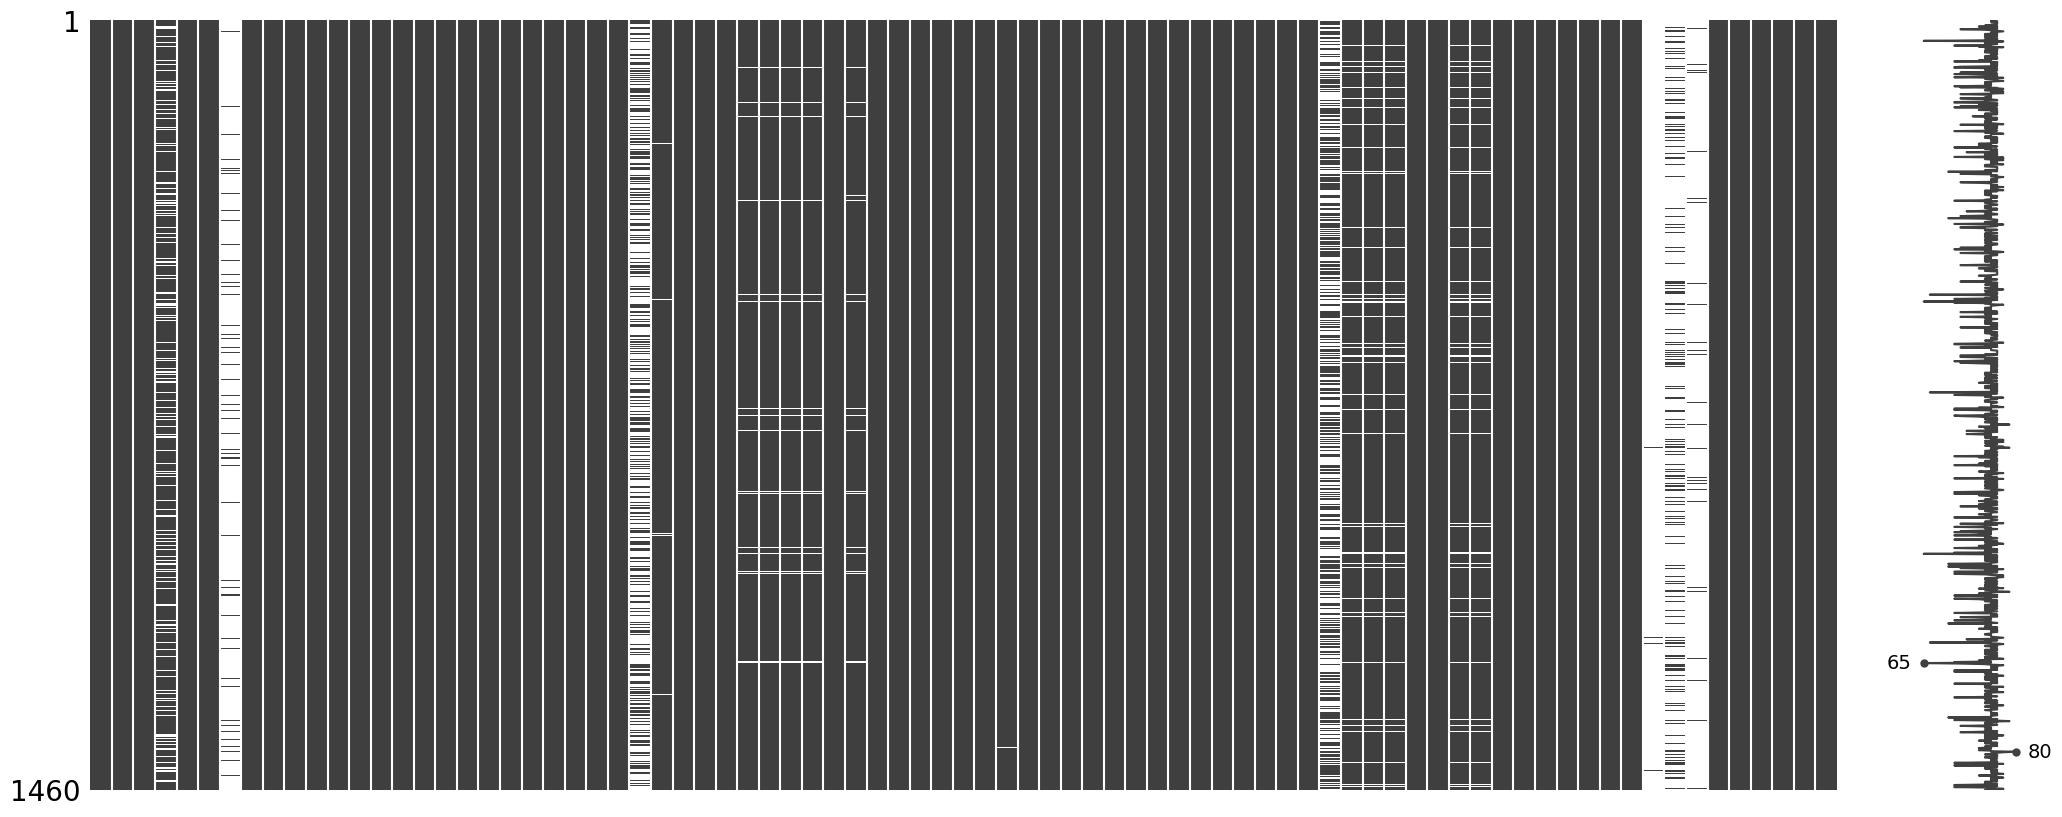

In [9]:
import missingno as msno
msno.matrix(df)


In [10]:
df.isnull().sum().sort_values(ascending=False).head(20)
#df.isnull() → Checks each cell in the dataset and marks it as True if the value is missing (NaN).

#sum() → Counts how many missing values each column has.


#sort_values(ascending=False) → Sorts the columns in descending order (most missing values first).

#head(20) → Shows only the top 20 columns with the most missing values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [11]:

df.isnull()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1456,False,False,False,False,False,False,True,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1457,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [12]:
# data cleaning and feature engineering 
#Feature engineering means creating, transforming, or selecting the right inputs (features) for a machine learning model so that it can learn patterns better.
#In simple words: improving the dataset before giving it to the model.
df = df.drop(["PoolQC", "Alley", "MiscFeature", "Fence"], axis=1)
#Columns like PoolQC, Alley, MiscFeature, Fence have too many missing values (>50%).

#These are usually dropped because they don’t add much predictive power.

In [13]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)



In [14]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["GarageType"] = df["GarageType"].fillna("None")
df["BsmtQual"]   = df["BsmtQual"].fillna("None")
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])


In [15]:
df.isnull().sum().sort_values(ascending=False).head(10)

FireplaceQu     690
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtFinType1     37
BsmtCond         37
BedroomAbvGr      0
dtype: int64

In [16]:
# Fireplace
df["FireplaceQu"] = df["FireplaceQu"].fillna("None")

# Garage-related
df["GarageFinish"] = df["GarageFinish"].fillna("None")
df["GarageQual"]   = df["GarageQual"].fillna("None")
df["GarageCond"]   = df["GarageCond"].fillna("None")
df["GarageYrBlt"]  = df["GarageYrBlt"].fillna(0)

# Basement-related
df["BsmtFinType2"] = df["BsmtFinType2"].fillna("None")
df["BsmtExposure"] = df["BsmtExposure"].fillna("None")
df["BsmtCond"]     = df["BsmtCond"].fillna("None")
df["BsmtFinType1"] = df["BsmtFinType1"].fillna("None")


In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)


Id              0
HalfBath        0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
BedroomAbvGr    0
FullBath        0
dtype: int64

In [18]:
# checking datatypes like they are categorical(object) or numerical(int or float )
df.dtypes


Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 77, dtype: object

In [19]:
#Encoding means converting text data (categories) into numbers, because machine learning models mostly understand 
#numbers, not words. encoding is part of feature engineering 
# label encoding
quality_map = {
    "Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0
}
df["ExterQual"] = df["ExterQual"].map(quality_map)
df["BsmtQual"] = df["BsmtQual"].map(quality_map)
df["FireplaceQu"] = df["FireplaceQu"].map(quality_map)


In [20]:
# one hot encoding 
df = pd.get_dummies(df, columns=["GarageType", "MSZoning", "Neighborhood"], drop_first=True)


In [21]:
#feature scaling
# Separate numerical and categorical features
num_features = df.select_dtypes(include=['int64', 'float64']).columns
cat_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)


Numerical Features: Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual',
       'BsmtQual', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')
Categorical Features: Index(['Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFin

In [22]:
# Drop SalePrice from scaling
num_features = num_features.drop("SalePrice")


In [23]:
!pip install numpy==1.26.4


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit & transform numerical features
df[num_features] = scaler.fit_transform(df[num_features])

In [26]:
from sklearn.preprocessing import LabelEncoder

# Copy the dataframe to avoid overwriting
df_encoded = df.copy()

# Encode categorical columns
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':  # if column is categorical
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

# Now split again
X = df_encoded.drop('SalePrice', axis=1)  # Features
y = df_encoded['SalePrice']              # Target

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize model
model = LinearRegression()

# Train on training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)


Mean Absolute Error: 19100.817022936815
Root Mean Squared Error: 31409.425012462143
R² Score: 0.8713807010334085


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train on training data
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("Mean Absolute Error:", mae_rf)
print("Root Mean Squared Error:", rmse_rf)
print("R² Score:", r2_rf)


Random Forest Results:
Mean Absolute Error: 17534.549452054795
Root Mean Squared Error: 28845.84803123956
R² Score: 0.8915192227598219


C:\Users\Dell\AppData\Local\Temp\ipykernel_7780\737108969.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp.head(20), palette="viridis")


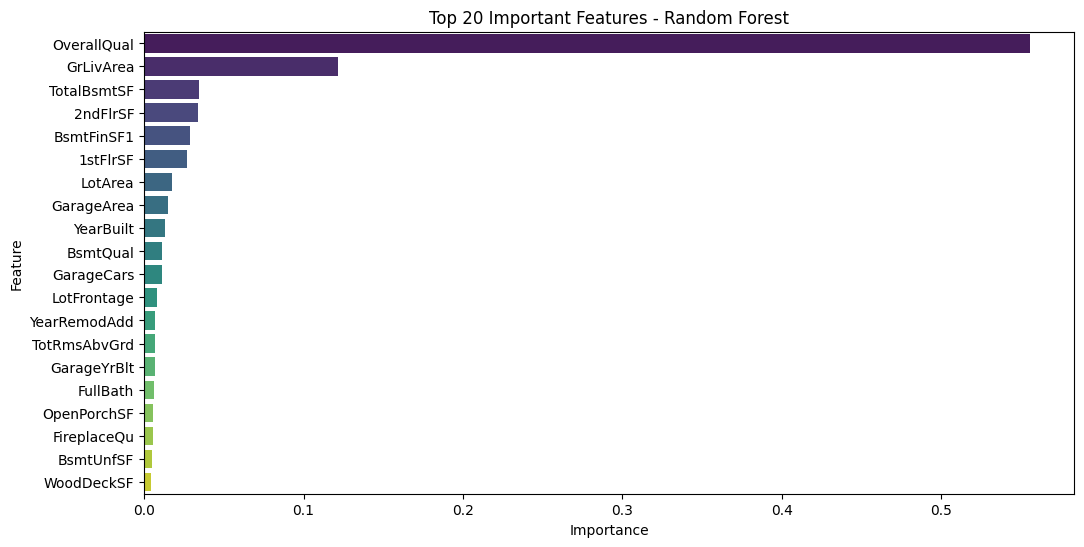

In [29]:
# Get feature importances
importances = rf_model.feature_importances_
features = X_train.columns

# Create a DataFrame for better visualization
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by="Importance", ascending=False)

# Plot the top 20 features
plt.figure(figsize=(12,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(20), palette="viridis")
plt.title("Top 20 Important Features - Random Forest")
plt.show()

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ---------- parameter distribution to search ----------
param_dist = {
    'n_estimators': [100, 200, 400, 800],         # number of trees
    'max_depth': [None, 10, 20, 30, 40],          # max depth of each tree
    'min_samples_split': [2, 5, 10],              # min samples required to split a node
    'min_samples_leaf': [1, 2, 4],                # min samples required at a leaf node
    'max_features': ['sqrt', 'log2', 0.2, 0.5],   # how many features to consider at each split
    'bootstrap': [True, False]
}

# initialize a plain RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                # tries 20 random combinations from the grid
    cv=3,                     # 3-fold cross-validation
    verbose=2,                # prints progress (set to 0 to silence)
    n_jobs=-1,                # use all available CPU cores
    random_state=42,
    scoring='neg_mean_squared_error'   # we minimize MSE -> sklearn uses negative MSE
)

# Fit the search on the training set
random_search.fit(X_train, y_train)

# Show best parameters and best score (convert to RMSE for readability)
best_params = random_search.best_params_
best_neg_mse = random_search.best_score_
best_rmse_cv = np.sqrt(-best_neg_mse)

print("Best Parameters:", best_params)
print("Best CV RMSE:", best_rmse_cv)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.2, 'max_depth': 40, 'bootstrap': False}
Best CV RMSE: 28559.596780110107


In [32]:
# Option A: use best_estimator_ directly
best_rf = random_search.best_estimator_

# or Option B: rebuild with best_params explicitly (same result)
# from sklearn.ensemble import RandomForestRegressor
# best_rf = RandomForestRegressor(**best_params, random_state=42)
# best_rf.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R²:", r2)

# Feature importance of the tuned model
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feat_imp.head(20))


Test MAE: 16622.953464418217
Test RMSE: 28034.233805690157
Test R²: 0.8975378303551559
OverallQual     0.182608
GrLivArea       0.119564
ExterQual       0.088164
GarageCars      0.084029
YearBuilt       0.054955
TotalBsmtSF     0.052696
BsmtQual        0.052194
1stFlrSF        0.040362
GarageArea      0.037424
2ndFlrSF        0.031183
BsmtFinSF1      0.023535
GarageYrBlt     0.022386
FullBath        0.020261
KitchenQual     0.019750
LotArea         0.019411
FireplaceQu     0.013567
Fireplaces      0.012843
TotRmsAbvGrd    0.012476
YearRemodAdd    0.011500
LotFrontage     0.006671
dtype: float64


In [33]:
# Save tuned model
import joblib
joblib.dump(best_rf, "rf_tuned_model.pkl")

# If you want to fine-tune around the best params, use GridSearchCV with a narrow grid
# Example: grid = {'max_depth': [best_params['max_depth']-5, best_params['max_depth'], best_params['max_depth']+5], ...}

# Or try cross_val_score for a stable CV estimate:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(best_rf, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_scores = np.sqrt(-scores)
print("5-fold CV RMSE mean:", rmse_scores.mean(), "std:", rmse_scores.std())


5-fold CV RMSE mean: 28434.75119538542 std: 4278.297273076719


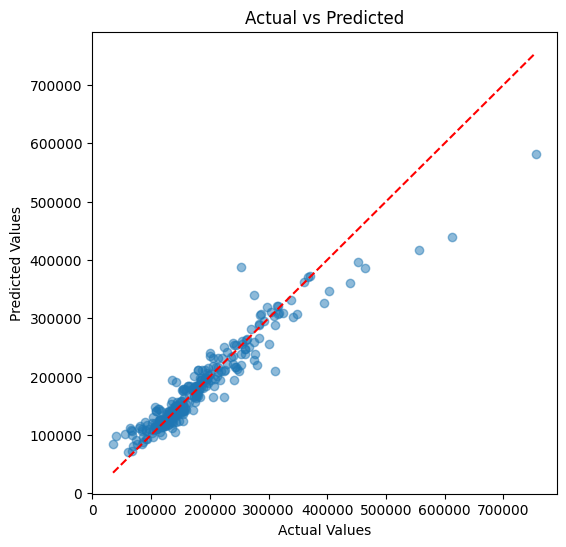

In [34]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()
# as we can see the blue sports are near aroud the red line , it means our model is giving good and stable performance .

In [36]:
import joblib
joblib.dump(rf_model, "house_price_model.pkl")


['house_price_model.pkl']

In [36]:
import os
print(os.getcwd())


C:\Users\Dell\Desktop\housepriceprediction
